In [ ]:
import os

# 1. Create a directory named .kaggle
!mkdir -p ~/.kaggle

# 2. Move the kaggle.json file into the newly created .kaggle directory
!mv /content/kaggle.json ~/.kaggle/

# 3. Set the file permissions for kaggle.json to be read/write only for the owner (0600)
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API setup complete.")

mv: cannot stat '/content/kaggle.json': No such file or directory
Kaggle API setup complete.


In [ ]:
print("Downloading and unzipping the dataset...")
!kaggle datasets download xhlulu/140k-real-and-fake-faces --unzip
print("Dataset download and unzip complete.")

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
User cancelled operation
Dataset download and unzip complete.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2. Define IMAGE_SIZE and BATCH_SIZE
IMAGE_SIZE = (96,96)
BATCH_SIZE = 32

# 3. Define the paths for the training and validation data directories
TRAIN_DIR = '/content/real_vs_fake/real-vs-fake/train'
VALID_DIR = '/content/real_vs_fake/real-vs-fake/valid'

# 4. Initialize a training ImageDataGenerator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

# 5. Initialize a validation ImageDataGenerator with only rescaling
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

# 6. Create the training data generator
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

# 7. Create the validation data generator
validation_generator = validation_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("ImageDataGenerators and data generators created.")

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
ImageDataGenerators and data generators created.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# 2. Load the pre-trained MobileNetV2 model
base_model = MobileNetV2(input_shape=IMAGE_SIZE + (3,), include_top=False, weights='imagenet')

# 3. Freeze the base model layers
base_model.trainable = False

# 4. Create the custom classification layers on top of the base model
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x) # Adding dropout for regularization
outputs = layers.Dense(1, activation='sigmoid')(x)

# Create the full model
model = models.Model(inputs=base_model.input, outputs=outputs)

# 5. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()
print("Transfer learning model built and compiled.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Transfer learning model built and compiled.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 1. Define callbacks
# EarlyStopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# ModelCheckpoint to save the best model weights
model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras', # Path to save the model file
    monitor='val_accuracy',       # Monitor validation accuracy
    save_best_only=True,          # Save only the best model
    mode='max',                   # Save model with maximum validation accuracy
    verbose=1                     # Log messages when best model is saved
)

# 2. Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=300,   # instead of 3125
    validation_data=validation_generator,
    validation_steps=100,
    epochs=5,
    callbacks=[early_stopping, model_checkpoint]
)

print("Model training complete.")

Epoch 1/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6263 - loss: 0.6696
Epoch 1: val_accuracy improved from -inf to 0.89781, saving model to best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 58s 137ms/step - accuracy: 0.6264 - loss: 0.6694 - val_accuracy: 0.8978 - val_loss: 0.3606
Epoch 2/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6750 - loss: 0.6012
Epoch 2: val_accuracy improved from 0.89781 to 0.95656, saving model to best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 120ms/step - accuracy: 0.6750 - loss: 0.6012 - val_accuracy: 0.9566 - val_loss: 0.2755
Epoch 3/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7002 - loss: 0.5764
Epoch 3: val_accuracy did not improve from 0.95656
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - accuracy: 0.7002 - loss: 0.5764 - val_accuracy: 0.9091 - val_loss: 0.3254
Epoch 4/5
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.7210 - loss: 0.5516
Epoch 4: val_accuracy did not improve from 0.95656
300/300 ━━━━━━━

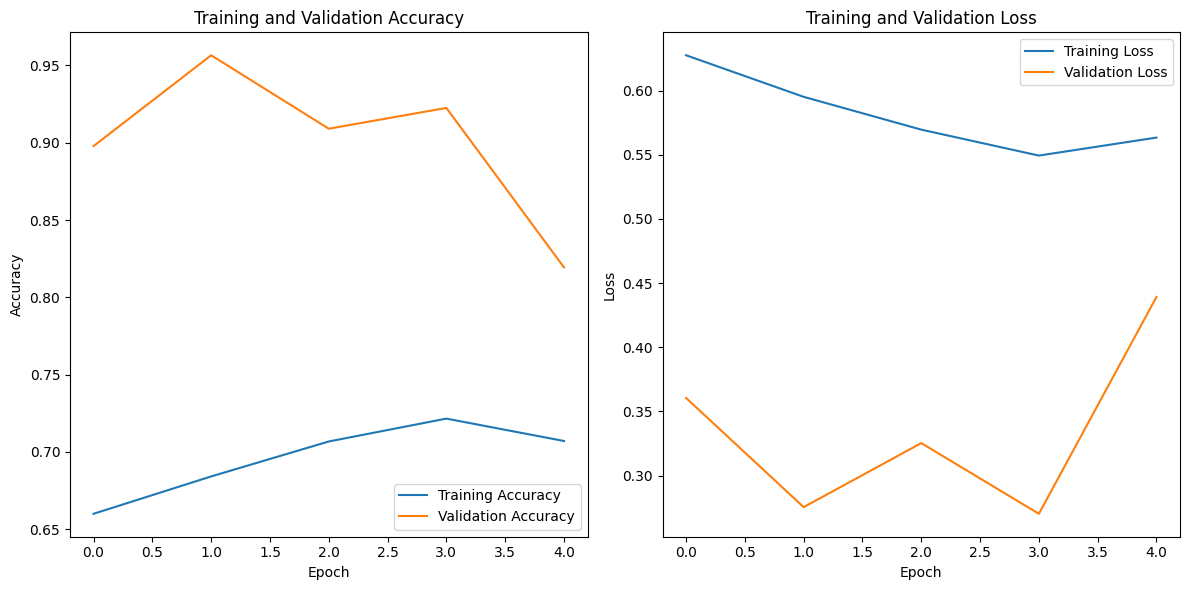

Training history plots displayed.


In [ ]:
import matplotlib.pyplot as plt

# Get training history from the 'history' object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot Training and Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

print("Training history plots displayed.")

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Assuming `model` and `IMAGE_SIZE` are already defined from previous steps

def predict_face_type(image_path):
    """
    Predicts whether a face in an image is 'Real' or 'Fake'.

    Args:
        image_path (str): The path to the image file.

    Returns:
        tuple: A tuple containing the predicted class ('Real' or 'Fake')
               and the confidence score (float).
    """
    try:
        # 1. Load and resize the image
        img = load_img(image_path, target_size=IMAGE_SIZE)

        # 2. Convert the image to a NumPy array
        img_array = img_to_array(img)

        # 3. Preprocess the image array
        # Rescale pixel values to [0, 1]
        img_array = img_array / 255.0
        # Expand dimensions to create a batch dimension (e.g., (1, 128, 128, 3))
        img_array = np.expand_dims(img_array, axis=0)

        # 4. Use the trained model to make a prediction
        prediction = model.predict(img_array)[0][0]

        # 5. Interpret the prediction
        if prediction >= 0.5:
            predicted_class = 'Real'
            confidence_score = prediction
        else:
            predicted_class = 'Fake'
            confidence_score = 1 - prediction # Confidence for 'Fake'

        return predicted_class, confidence_score

    except Exception as e:
        return f"Error: {e}", None

print("Prediction function `predict_face_type` defined.")


Prediction function `predict_face_type` defined.


In [ ]:
import os

# Construct the full paths to the 'real' and 'fake' subdirectories within TRAIN_DIR
real_images_dir = os.path.join(TRAIN_DIR, 'real')
fake_images_dir = os.path.join(TRAIN_DIR, 'fake')

# Get a list of all file names in the 'real' images directory
real_image_filenames = os.listdir(real_images_dir)

# Get a list of all file names in the 'fake' images directory
fake_image_filenames = os.listdir(fake_images_dir)

# Select the first few filenames (e.g., the first 5) from each list
sample_real_filenames = real_image_filenames[:5]
sample_fake_filenames = fake_image_filenames[:5]

# Construct the full paths for these sample real and fake images
sample_real_images_paths = [os.path.join(real_images_dir, filename) for filename in sample_real_filenames]
sample_fake_images_paths = [os.path.join(fake_images_dir, filename) for filename in sample_fake_filenames]

print("Sample Real Image Paths:")
for path in sample_real_images_paths:
    print(path)

print("\nSample Fake Image Paths:")
for path in sample_fake_images_paths:
    print(path)

Sample Real Image Paths:
/content/real_vs_fake/real-vs-fake/train/real/11954.jpg
/content/real_vs_fake/real-vs-fake/train/real/18945.jpg
/content/real_vs_fake/real-vs-fake/train/real/11308.jpg
/content/real_vs_fake/real-vs-fake/train/real/59323.jpg
/content/real_vs_fake/real-vs-fake/train/real/61731.jpg

Sample Fake Image Paths:
/content/real_vs_fake/real-vs-fake/train/fake/VA2REUHGDM.jpg
/content/real_vs_fake/real-vs-fake/train/fake/Z533L0RKY8.jpg
/content/real_vs_fake/real-vs-fake/train/fake/2A0FWVX3MD.jpg
/content/real_vs_fake/real-vs-fake/train/fake/1RJTV5C0JU.jpg
/content/real_vs_fake/real-vs-fake/train/fake/K5GWJ4MFP7.jpg


In [ ]:
print("Demonstrating prediction function with sample images:")

# Predict for a sample real image
if sample_real_images_paths:
    real_image_path = sample_real_images_paths[0]
    predicted_class_real, confidence_real = predict_face_type(real_image_path)
    print(f"\nPrediction for Real Image ('{os.path.basename(real_image_path)}'): Class={predicted_class_real}, Confidence={confidence_real:.4f}")
else:
    print("No sample real images found.")

# Predict for a sample fake image
if sample_fake_images_paths:
    fake_image_path = sample_fake_images_paths[0]
    predicted_class_fake, confidence_fake = predict_face_type(fake_image_path)
    print(f"Prediction for Fake Image ('{os.path.basename(fake_image_path)}'): Class={predicted_class_fake}, Confidence={confidence_fake:.4f}")
else:
    print("No sample fake images found.")


Demonstrating prediction function with sample images:
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step

Prediction for Real Image ('11954.jpg'): Class=Real, Confidence=0.6535
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction for Fake Image ('VA2REUHGDM.jpg'): Class=Fake, Confidence=0.7070


In [ ]:
image_path = "/content/fake3.jpg"

label, conf = predict_face_type(image_path)

print(f"Prediction: {label}")
print(f"Confidence: {conf:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Prediction: Fake
Confidence: 0.96
